<a href="https://colab.research.google.com/github/osh9149/2026_DataScience/blob/main/%EC%A0%84%EA%B5%AD%EB%8C%80%ED%95%99%EC%A0%95%EB%B3%B4%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 데이터 분석 및 시각화를 위한 패키지 호출
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

In [ ]:
#구글드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#폰트설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree       
Reading state information... Done
fonts-nanum is already the newest version (20170925-1).
The following packages were automatically installed and are no longer required:
  libnvidia-common-460 nsight-compute-2020.2.0
Use 'sudo apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 10 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconf

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/2022_DataScience/school_location.xlsx', thousands = ',')
df.head()

,시도,행정구,학교명,학교명(영문),설립,우편번호,주소,위도,경도,전화번호,팩스번호,홈페이지
0,강원,강원 춘천시,춘천교육대학교,Chuncheon National University of Education,국립,24328,"강원도 춘천시 공지로 126 (석사동, 춘천교육대학교)",37.859013,127.748348,033-260-6000,033-261-4328,www.cnue.ac.kr
1,강원,강원 강릉시,가톨릭관동대학교,Catholic Kwandong University,사립,25601,"강원도 강릉시 범일로579번길 24 (내곡동, 가톨릭관동대학교)",37.736276,128.874035,033-649-7114,033-649-7874,www.cku.ac.kr
2,강원,강원 강릉시,강릉원주대학교,Gangneung-Wonju National University,국립,25457,"강원도 강릉시 죽헌길 7 (지변동, 강릉원주대학교)",37.770132,128.869074,033-640-7001,033-643-7110,www.gwnu.ac.kr
3,강원,강원 원주시,강릉원주대학교,Gangneung-Wonju National University,국립,26403,"강원도 원주시 흥업면 남원로 150 (흥업리, 강릉원주대학교원주캠퍼스)",37.304697,127.922635,033-760-8114,033-760-8019,www.gwnu.ac.kr
4,강원,강원 춘천시,강원대학교,Kangwon National University,국립,24341,"강원도 춘천시 강원대학길 1 (효자동, 강원대학교)",37.868231,127.744203,033-250-6114,033-251-9556,www.kangwon.ac.kr/


In [ ]:
df.tail()

,시도,행정구,학교명,학교명(영문),설립,우편번호,주소,위도,경도,전화번호,팩스번호,홈페이지
294,충북,충북 청주시,충북대학교,Chungbuk National University,국립,28644,"충청북도 청주시 서원구 충대로 1 (개신동, 충북대학교)",36.625900,127.466592,"043-261-2114,3114",043-263-0612,www.chungbuk.ac.kr
295,충북,충북 청주시,한국교원대학교,Korea National University Of Education,국립,28173,"충청북도 청주시 흥덕구 강내면 태성탑연로 250 (다락리, 한국교원대학교)",36.608356,127.358221,043-230-3114,043-233-2960,www.knue.ac.kr
296,충북,충북 충주시,한국교통대학교,KOREA NATIONAL UNIVERSITY OF TRANSPORTATION,국립,27469,"충청북도 충주시 대소원면 대학로 50 (검단리, 한국교통대학교)",36.969728,127.871322,043-841-5000,043-853-1236,www.ut.ac.kr
297,충북,충북 제천시,순복음총회신학교,Korea Christian College,사립,27223,충청북도 제천시 덕산면 도전로 320 (도전리),36.904228,128.167540,043-645-5571,043-642-4530,www.kcc.ac.kr
298,충북,충북 청주시,한국폴리텍IV 대학 청주캠퍼스,Cheongju Campus of Korea Polytechnic,사립,28590,"충청북도 청주시 흥덕구 산단로 54 (송정동, 한국폴리텍Ⅳ대학청주캠퍼스)",36.638963,127.448913,043-279-7400,043-279-7477,www.kopo.ac.kr/cheongju


In [ ]:
df

,시도,행정구,학교명,학교명(영문),설립,우편번호,주소,위도,경도,전화번호,팩스번호,홈페이지
0,강원,강원 춘천시,춘천교육대학교,Chuncheon National University of Education,국립,24328,"강원도 춘천시 공지로 126 (석사동, 춘천교육대학교)",37.859013,127.748348,033-260-6000,033-261-4328,www.cnue.ac.kr
1,강원,강원 강릉시,가톨릭관동대학교,Catholic Kwandong University,사립,25601,"강원도 강릉시 범일로579번길 24 (내곡동, 가톨릭관동대학교)",37.736276,128.874035,033-649-7114,033-649-7874,www.cku.ac.kr
2,강원,강원 강릉시,강릉원주대학교,Gangneung-Wonju National University,국립,25457,"강원도 강릉시 죽헌길 7 (지변동, 강릉원주대학교)",37.770132,128.869074,033-640-7001,033-643-7110,www.gwnu.ac.kr
3,강원,강원 원주시,강릉원주대학교,Gangneung-Wonju National University,국립,26403,"강원도 원주시 흥업면 남원로 150 (흥업리, 강릉원주대학교원주캠퍼스)",37.304697,127.922635,033-760-8114,033-760-8019,www.gwnu.ac.kr
4,강원,강원 춘천시,강원대학교,Kangwon National University,국립,24341,"강원도 춘천시 강원대학길 1 (효자동, 강원대학교)",37.868231,127.744203,033-250-6114,033-251-9556,www.kangwon.ac.kr/
...,...,...,...,...,...,...,...,...,...,...,...,...
294,충북,충북 청주시,충북대학교,Chungbuk National University,국립,28644,"충청북도 청주시 서원구 충대로 1 (개신동, 충북대학교)",36.625900,127.466592,"043-261-2114,3114",043-263-0612,www.chungbuk.ac.kr
295,충북,충북 청주시,한국교원대학교,Korea National University Of Education,국립,28173,"충청북도 청주시 흥덕구 강내면 태성탑연로 250 (다락리, 한국교원대학교)",36.608356,127.358221,043-230-3114,043-233-2960,www.knue.ac.kr
296,충북,충북 충주시,한국교통대학교,KOREA NATIONAL UNIVERSITY OF TRANSPORTATION,국립,27469,"충청북도 충주시 대소원면 대학로 50 (검단리, 한국교통대학교)",36.969728,127.871322,043-841-5000,043-853-1236,www.ut.ac.kr
297,충북,충북 제천시,순복음총회신학교,Korea Christian College,사립,27223,충청북도 제천시 덕산면 도전로 320 (도전리),36.904228,128.167540,043-645-5571,043-642-4530,www.kcc.ac.kr


In [ ]:

df1=df.sort_values(by='학교명', ascending=False)
df1

,시도,행정구,학교명,학교명(영문),설립,우편번호,주소,위도,경도,전화번호,팩스번호,홈페이지
152,부산,부산 연제구,화신사이버대학교,Hwashin Cyber University,사립,47558,"부산광역시 연제구 고분로191번길 1 (연산동, 화신사이버대학교)",35.185616,129.103207,051-999-0121,051-999-0119,www.hscu.ac.kr
221,세종,세종,홍익대학교 세종캠퍼스,Hongik University,사립,30016,"세종특별자치시 조치원읍 세종로 2639 (신안리, 홍익대학교세종캠퍼스)",36.620982,127.287357,044-860-2114,044-860-2238,http://sejong.hongik.ac.kr/index.do
220,세종,세종,홍익대학교 세종캠퍼스,Hongik University,사립,30016,"세종특별자치시 조치원읍 세종로 2639 (신안리, 홍익대학교세종캠퍼스)",36.620982,127.287357,044-860-2114,044-860-2238,sejong.hongik.ac.kr
196,서울,서울 마포구,홍익대학교,Hongik University,사립,4066,"서울특별시 마포구 와우산로 94 (상수동, 홍익대학교)",37.548424,126.925234,02-320-1114,02-320-1122,www.hongik.ac.kr/
257,전북,전북 군산시,호원대학교,HOWON University,사립,54058,"전라북도 군산시 임피면 호원대3길 64 (월하리, 호원대학교)",35.966034,126.864882,063-450-7114,063-450-7777,www.howon.ac.kr
...,...,...,...,...,...,...,...,...,...,...,...,...
74,경북,경북 고령군,가야대학교,KAYA UNIVERSITY,사립,40139,"경상북도 고령군 대가야읍 대가야로 1103 (지산리, 가야대학교)",35.716105,128.251565,055-330-1000,055-331-0112,http://www.kaya.ac.kr
200,서울,서울 동작구,SPC식품과학대학,SPC College Of Food Sciece,사립,7068,서울특별시 동작구 신대방16다길 14 (신대방동),37.491303,126.909563,02-6331-3519,NaN,NaN
133,대전,대전 유성구,LH토지주택대학교,LHU(LH University),사립,34047,"대전광역시 유성구 엑스포로539번길 99 (전민동, LH토지주택연구원)",36.404843,127.400031,NaN,NaN,NaN
201,서울,서울 영등포구,KDB금융대학교,KDB FINANCIAL UNIVERSITY,사립,7242,"서울특별시 영등포구 은행로 14 (여의도동, 산업은행본점)",37.527992,126.920852,02-787-6327,02-787-5595,kfu.kdb.co.kr


In [ ]:
df2=df.groupby('시도').count()
df2

,행정구,학교명,학교명(영문),설립,우편번호,주소,위도,경도,전화번호,팩스번호,홈페이지
시도,,,,,,,,,,,
강원,15,15,15,15,15,15,15,15,15,14,14
경기,44,44,44,44,44,44,44,44,42,38,42
경남,15,15,15,15,15,15,15,15,15,15,13
경북,26,26,26,26,26,26,26,26,26,25,25
광주,12,12,12,12,12,12,12,12,12,12,12
대구,7,7,7,7,7,7,7,7,7,6,7
대전,17,17,17,17,17,17,17,17,16,15,16
부산,18,18,18,18,18,18,18,18,18,18,18
서울,64,64,64,64,64,64,64,64,63,53,62


In [ ]:
plt.rc('font', family='NanumBarunGothic')

plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.color'] = 'red'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.edgecolor'] = "b"
plt.rcParams['axes.facecolor'] = "yellow"


Text(0, 0.5, '개수')

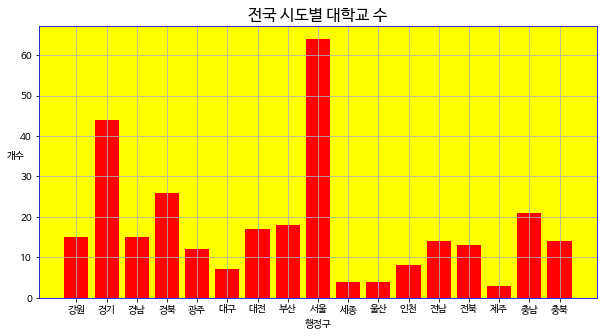

In [ ]:
# plt.scatter(df2.index, df2['행정구'], color='red')
plt.bar(df2.index, df2['행정구'], color='red')

plt.title('전국 시도별 대학교 수', fontsize=16)
plt.xlabel('행정구')
plt.ylabel('개수',rotation='horizontal')

Text(0, 0.5, '개수')

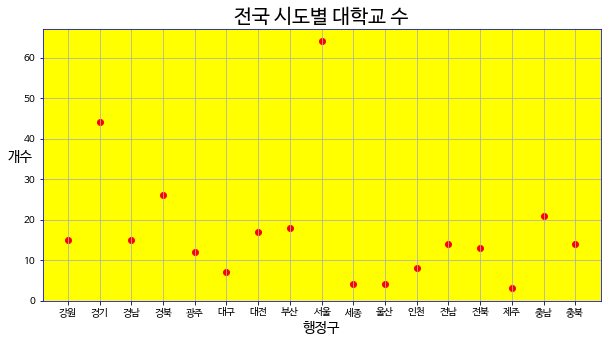

In [ ]:
plt.scatter(df2.index, df2['행정구'], color='red')

plt.title('전국 시도별 대학교 수', fontsize=20)
plt.xlabel('행정구', fontsize=14)
plt.ylabel('개수',rotation='horizontal',fontsize=14)

In [ ]:

school_map = folium.Map(
    location=[37.573050, 126.979189], tiles ='OpenStreetMap' , zoom_start=7)

for idx in df.index:
    lat = df.loc[idx, '위도']
    lng = df.loc[idx, '경도']

    folium.CircleMarker(
        location=[lat, lng],
        color='#d0ff00',
        fill_color='#e77878',
        fill_opacity=0.9,
        weight=1,
        radius=5
    ).add_to(school_map)

school_map